# 🚀 NVIDIA A100 GPU Master Training Pipeline: 3 Machine Translation Architectures
### End-to-End Multilingual NMT (English ↔ Kiswahili ↔ Ekegusii) for Kenyan Public Service Announcements

This 100% full, standalone Jupyter Notebook executes data cleaning, subword tokenization, stratified splitting, multi-stage fine-tuning, and automated evaluation for **3 distinct Machine Translation Architectures** using Meta NLLB-200 / MarianMT with LoRA (`peft`) on an **NVIDIA A100-SXM4-80GB GPU**.

---
### 🏛️ The 3 Experimental Architectures:

1. **Architecture 1: Direct Trilingual Fine-Tuning**
   - Fine-tunes directly on Trilingual PSA Data (`psa.csv`).

2. **Architecture 2: Sequential Transfer Learning**
   - Fine-tunes on **Bilingual Data** (`English_Ekegusii_Web_News.csv`) → Transfer to **Trilingual Bible Data** (`bibile.csv`) → Transfer to **Trilingual PSA Data** (`psa.csv`).

3. **Architecture 3: Progressive Curriculum Transfer Learning**
   - Pre-trains/adapts on **Unilingual Monolingual PSAs** (`english_unilingual.csv`) → Transfer to **Bilingual Data** → Transfer to **Trilingual Bible Data** → Transfer to **Trilingual PSA Data**.

*Note: All 3 architectures are evaluated on the exact same held-out 10% test benchmark to ensure a 100% fair and objective comparison.*

## 1. Environment Setup & NVIDIA A100 GPU Verification
Installs necessary dependencies (`transformers`, `peft`, `datasets`, `evaluate`, `sacrebleu`, `accelerate`) and verifies GPU hardware specifications.

In [1]:
# Install all required packages with latest upgrades
%pip install -U \
transformers \
peft \
datasets \
evaluate \
sacrebleu \
accelerate \
sentencepiece \
bitsandbytes \
matplotlib \
pandas \
numpy \
scikit-learn \
chrf \
seaborn

import torch
import transformers
import peft
import datasets
import evaluate
import os
import sys
import glob

print('=== GPU Hardware & Environment Info ===')
print('PyTorch Version:', torch.__version__)
print('CUDA Available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU Device Name:', torch.cuda.get_device_name(0))
    print('Total VRAM:', f'{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('WARNING: Running on CPU. NVIDIA A100 GPU recommended for fast training.')

ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 2.5.0 Requires-Python >=3.12; 2.5.0rc1 Requires-Python >=3.12; 2.5.1 Requires-Python >=3.12
ERROR: Could not find a version that satisfies the requirement chrf (from versions: none)
ERROR: No matching distribution found for chrf
Note: you may need to restart the kernel to use updated packages.
=== GPU Hardware & Environment Info ===
PyTorch Version: 2.13.0+cu130
CUDA Available: True
GPU Device Name: NVIDIA A100-SXM4-80GB
Total VRAM: 85.09 GB


## 2. Dynamic Auto-Path Data Resolver & Stratified Architecture Splitting
Searches current directory and parent directory (`../data/`) for your uploaded CSV datasets (`psa.csv`, `bibile.csv`, `English_Ekegusii_Web_News.csv`, `english_unilingual.csv`), performs Unicode cleaning, and constructs clean 80/10/10 train/val/test splits for all 3 architectures.

In [2]:
import pandas as pd
import re
import glob
from sklearn.model_selection import train_test_split

def find_data_file(filename):
    possible_paths = [
        # Subfolder level (when running inside /notebook/ or /notebooks/)
        os.path.join('..', 'data', 'data_trian_tringual', filename),
        os.path.join('..', 'data', 'data_train_bilingual', filename),
        os.path.join('..', 'data', 'data_train_unilingual', filename),
        os.path.join('..', 'data_trian_tringual', filename),
        os.path.join('..', 'data_train_bilingual', filename),
        os.path.join('..', 'data_train_unilingual', filename),
        # Root level
        os.path.join('data', 'data_trian_tringual', filename),
        os.path.join('data', 'data_train_bilingual', filename),
        os.path.join('data', 'data_train_unilingual', filename),
        os.path.join('data_trian_tringual', filename),
        os.path.join('data_train_bilingual', filename),
        os.path.join('data_train_unilingual', filename),
        filename,
        os.path.join('..', filename)
    ]
    for p in possible_paths:
        if os.path.exists(p):
            return p
    matches = glob.glob(f'**/{filename}', recursive=True) + glob.glob(f'../**/{filename}', recursive=True)
    if matches:
        return matches[0]
    raise FileNotFoundError(f'Could not locate dataset file "{filename}" in current ({os.getcwd()}) or parent directory.')

def clean_text(text):
    if pd.isna(text) or not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'^[\"\'`]+|[\"\'`]+$', '', text).strip()
    return text

print('=== Auto-Resolving Uploaded Dataset Paths & Creating Architecture Splits ===')
print('Jupyter Working Directory:', os.getcwd())

psa_path = find_data_file('psa.csv')
print(f'[FOUND] Trilingual PSA Dataset located at: "{psa_path}"')

splits_root = 'data_splits'
arch1_dir = os.path.join(splits_root, 'arch1_direct_trilingual_psa')
arch2_dir = os.path.join(splits_root, 'arch2_bilingual_bible_psa')
arch3_dir = os.path.join(splits_root, 'arch3_curriculum_learning')

for d in [arch1_dir, arch2_dir, arch3_dir]:
    os.makedirs(d, exist_ok=True)

# Load & Clean Trilingual PSA
psa_df = pd.read_csv(psa_path)
for col in ['English', 'Kiswahili', 'Ekegusii']:
    if col in psa_df.columns:
        psa_df[col] = psa_df[col].apply(clean_text)

psa_df = psa_df[(psa_df['English'].str.len() > 3) & (psa_df['Kiswahili'].str.len() > 3) & (psa_df['Ekegusii'].str.len() > 3)].drop_duplicates().reset_index(drop=True)

# 80/10/10 Stratified Split
train_psa, temp_psa = train_test_split(psa_df, test_size=0.20, random_state=42)
val_psa, test_psa = train_test_split(temp_psa, test_size=0.50, random_state=42)

# Save Arch 1 Splits
train_psa.to_csv(os.path.join(arch1_dir, 'train.csv'), index=False)
val_psa.to_csv(os.path.join(arch1_dir, 'val.csv'), index=False)
test_psa.to_csv(os.path.join(arch1_dir, 'test.csv'), index=False)

# Save Arch 2 & 3 Shared Held-Out Test & Val Sets
for d in [arch2_dir, arch3_dir]:
    val_psa.to_csv(os.path.join(d, 'val.csv'), index=False)
    test_psa.to_csv(os.path.join(d, 'test.csv'), index=False)

print(f'[OK] Splits Created! Train: {len(train_psa)} | Val: {len(val_psa)} | Held-out Test: {len(test_psa)}')
print('[CONFIRMED] Uploaded Files Detected Successfully:')
print(' -> Bilingual Web News:', find_data_file('English_Ekegusii_Web_News.csv'))
print(' -> Trilingual Bible:', find_data_file('bibile.csv'))
print(' -> Unilingual English:', find_data_file('english_unilingual.csv'))

=== Auto-Resolving Uploaded Dataset Paths & Creating Architecture Splits ===
Jupyter Working Directory: /home/jovyan/notebook
[FOUND] Trilingual PSA Dataset located at: "../data/data_trian_tringual/psa.csv"
[OK] Splits Created! Train: 2225 | Val: 278 | Held-out Test: 279
[CONFIRMED] Uploaded Files Detected Successfully:
 -> Bilingual Web News: ../data/data_train_bilingual/English_Ekegusii_Web_News.csv
 -> Trilingual Bible: ../data/data_trian_tringual/bibile.csv
 -> Unilingual English: ../data/data_train_unilingual/english_unilingual.csv


## 3. NMT Tokenization, Model & Metric Utility Setup
Defines NLLB-200 tokenization with language tags (`eng_Latn`, `swh_Latn`), LoRA PEFT model configuration, Hugging Face `Seq2SeqTrainer`, and SacreBLEU / chrF evaluation metric computation.

In [8]:
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from peft import LoraConfig, get_peft_model, TaskType

device = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'facebook/nllb-200-distilled-600M'
LANG_TAGS = {'English': 'eng_Latn', 'Kiswahili': 'swh_Latn', 'Ekegusii': 'swh_Latn'}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bleu_metric = evaluate.load('sacrebleu')
chrf_metric = evaluate.load('chrf')

def preprocess_nmt_function(examples, src_lang='English', tgt_lang='Ekegusii'):
    inputs = [str(x) for x in examples[src_lang]]
    targets = [str(x) for x in examples[tgt_lang]]
    tokenizer.src_lang = LANG_TAGS.get(src_lang, 'eng_Latn')
    tokenizer.tgt_lang = LANG_TAGS.get(tgt_lang, 'swh_Latn')
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding=False)
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding=False)
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]
    bleu = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels)
    chrf = chrf_metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {'bleu': bleu['score'], 'chrf': chrf['score']}

def evaluate_on_test(model, test_df, src_lang='English', tgt_lang='Ekegusii'):
    test_ds = Dataset.from_pandas(test_df).map(
        lambda x: preprocess_nmt_function(x, src_lang, tgt_lang),
        batched=True
    )

    training_args = Seq2SeqTrainingArguments(
        output_dir='./tmp_eval',
        per_device_eval_batch_size=32,
        predict_with_generate=True,
        bf16=torch.cuda.is_bf16_supported(),
        report_to='none'
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        processing_class=tokenizer,   # <-- changed from tokenizer=
        data_collator=DataCollatorForSeq2Seq(
            tokenizer=tokenizer,
            model=model
        ),
        compute_metrics=compute_metrics
    )

    results = trainer.evaluate(test_ds)

    return results.get('eval_bleu', 0.0), results.get('eval_chrf', 0.0)

print('[OK] Tokenizer & NMT evaluation functions compiled.')

[OK] Tokenizer & NMT evaluation functions compiled.


## 4. Architecture 1 Execution: Direct Trilingual PSA Fine-Tuning
Fine-tunes Meta NLLB-200 with LoRA directly on the Trilingual PSA dataset (`arch1_direct_trilingual_psa/train.csv`).

In [9]:
print('=== RUNNING ARCHITECTURE 1: Direct Trilingual Fine-Tuning ===')

arch1_dir = os.path.join(splits_root, 'arch1_direct_trilingual_psa')

a1_train = pd.read_csv(os.path.join(arch1_dir, 'train.csv'))
a1_val = pd.read_csv(os.path.join(arch1_dir, 'val.csv'))
a1_test = pd.read_csv(os.path.join(arch1_dir, 'test.csv'))

# Load base model
base_model1 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

# LoRA configuration (Updated for latest PEFT)
peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

# Apply LoRA
a1_model = get_peft_model(base_model1, peft_config)
a1_model.print_trainable_parameters()

# Prepare datasets
train_ds1 = Dataset.from_pandas(a1_train).map(
    lambda x: preprocess_nmt_function(x, 'English', 'Ekegusii'),
    batched=True
)

val_ds1 = Dataset.from_pandas(a1_val).map(
    lambda x: preprocess_nmt_function(x, 'English', 'Ekegusii'),
    batched=True
)

# Training arguments
args1 = Seq2SeqTrainingArguments(
    output_dir='./output_arch1',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    predict_with_generate=True,
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=20,
    report_to='none'
)

# Trainer
trainer1 = Seq2SeqTrainer(
    model=a1_model,
    args=args1,
    train_dataset=train_ds1,
    eval_dataset=val_ds1,
    processing_class=tokenizer,
    data_collator=DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=a1_model
    ),
    compute_metrics=compute_metrics
)

# Train
trainer1.train()

# Evaluate
bleu1, chrf1 = evaluate_on_test(a1_model, a1_test)

print(f"\n🏆 Architecture 1 Final Test Results:")
print(f"SacreBLEU = {bleu1:.2f}")
print(f"chrF       = {chrf1:.2f}")

=== RUNNING ARCHITECTURE 1: Direct Trilingual Fine-Tuning ===


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

trainable params: 3,538,944 || all params: 618,612,736 || trainable%: 0.5721


Map:   0%|          | 0/2225 [00:00<?, ? examples/s]

Map:   0%|          | 0/278 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Bleu,Chrf
1,5.616786,5.169144,0.462298,8.533411
2,5.038387,4.779990,0.353907,10.980744
3,4.915127,4.681932,0.426301,11.945942


Map:   0%|          | 0/279 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Step,Bleu,Chrf
No log,4.736681,0,0.292757,12.181912



🏆 Architecture 1 Final Test Results:
SacreBLEU = 0.29
chrF       = 12.18


## 5. Architecture 2 Execution: Sequential Transfer Learning
Progressively transfers knowledge across 3 stages:
1. Stage 1: Fine-tune on **Bilingual Parallel Data** (`English_Ekegusii_Web_News.csv`)
2. Stage 2: Fine-tune on **Trilingual Bible Parallel Data** (`bibile.csv`)
3. Stage 3: Domain adaptation on **Trilingual PSA Data** (`psa.csv`)

In [11]:
print('=== RUNNING ARCHITECTURE 2: Sequential Transfer Learning ===')
bi_file = find_data_file('English_Ekegusii_Web_News.csv')
bible_file = find_data_file('bibile.csv')
a2_bi = pd.read_csv(bi_file)
a2_bible = pd.read_csv(bible_file)
a2_psa_train = a1_train
a2_val = a1_val
a2_test = a1_test

base_model2 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
a2_model = get_peft_model(base_model2, peft_config)

# Stage 1: Bilingual
print('-> Stage 1: Fine-tuning on Bilingual Data...')
ds2_1 = Dataset.from_pandas(a2_bi).map(lambda x: preprocess_nmt_function(x, 'English', 'Ekegusii'), batched=True)
args2_1 = Seq2SeqTrainingArguments(output_dir='./output_arch2_s1', per_device_train_batch_size=32, num_train_epochs=1, bf16=torch.cuda.is_bf16_supported(), report_to='none')
Seq2SeqTrainer(model=a2_model, args=args2_1, train_dataset=ds2_1, data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=a2_model)).train()

# Stage 2: Bible
print('-> Stage 2: Fine-tuning on Trilingual Bible Data...')
ds2_2 = Dataset.from_pandas(a2_bible.sample(min(4000, len(a2_bible)))).map(lambda x: preprocess_nmt_function(x, 'English', 'Ekegusii'), batched=True)
args2_2 = Seq2SeqTrainingArguments(output_dir='./output_arch2_s2', per_device_train_batch_size=32, num_train_epochs=1, bf16=torch.cuda.is_bf16_supported(), report_to='none')
Seq2SeqTrainer(model=a2_model, args=args2_2, train_dataset=ds2_2, data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=a2_model)).train()

# Stage 3: PSA Adaptation
print('-> Stage 3: Domain Adaptation on Trilingual PSA Data...')
ds2_3 = Dataset.from_pandas(a2_psa_train).map(lambda x: preprocess_nmt_function(x, 'English', 'Ekegusii'), batched=True)
ds2_val = Dataset.from_pandas(a2_val).map(lambda x: preprocess_nmt_function(x, 'English', 'Ekegusii'), batched=True)
args2_3 = Seq2SeqTrainingArguments(output_dir='./output_arch2_s3', eval_strategy='epoch', save_strategy='epoch', per_device_train_batch_size=32, per_device_eval_batch_size=32, num_train_epochs=3, predict_with_generate=True, bf16=torch.cuda.is_bf16_supported(), report_to='none')
trainer2 = Seq2SeqTrainer(model=a2_model, args=args2_3, train_dataset=ds2_3, eval_dataset=ds2_val, data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=a2_model), compute_metrics=compute_metrics)
trainer2.train()

bleu2, chrf2 = evaluate_on_test(a2_model, a2_test)
print(f'\n🏆 Architecture 2 Final Test Results: SacreBLEU = {bleu2:.2f} | chrF = {chrf2:.2f}')

=== RUNNING ARCHITECTURE 2: Sequential Transfer Learning ===


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

-> Stage 1: Fine-tuning on Bilingual Data...


Map:   0%|          | 0/4289 [00:00<?, ? examples/s]

Step,Training Loss


...

Map:   0%|          | 0/278 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Bleu,Chrf
1,No log,5.667831,2.867722,16.277823
2,No log,5.511881,2.308337,15.358426
3,No log,5.468167,2.143486,14.941542


Map:   0%|          | 0/279 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Step,Bleu,Chrf
No log,5.579866,0,1.423540,14.674446



🏆 Architecture 2 Final Test Results: SacreBLEU = 1.42 | chrF = 14.67


## 6. Architecture 3 Execution: Progressive Curriculum Transfer Learning
Progressively adapts models through 4 curriculum steps:
1. Unilingual PSAs (`english_unilingual.csv`) → 2. Bilingual Data → 3. Trilingual Bible → 4. Trilingual PSA Domain Adaptation

In [12]:
print('=== RUNNING ARCHITECTURE 3: Progressive Curriculum Transfer Learning ===')
uni_file = find_data_file('english_unilingual.csv')
a3_uni = pd.read_csv(uni_file)

base_model3 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
a3_model = get_peft_model(base_model3, peft_config)

# Stage 1: Unilingual Adaptation
print('-> Stage 1: Unilingual Monolingual PSA Pre-adaptation...')
uni_sample = a3_uni.sample(min(4000, len(a3_uni)))
uni_sample['Ekegusii'] = uni_sample['English'] # Self-copy for language adapter tuning
ds3_1 = Dataset.from_pandas(uni_sample).map(lambda x: preprocess_nmt_function(x, 'English', 'Ekegusii'), batched=True)
args3_1 = Seq2SeqTrainingArguments(output_dir='./output_arch3_s1', per_device_train_batch_size=32, num_train_epochs=1, bf16=torch.cuda.is_bf16_supported(), report_to='none')
Seq2SeqTrainer(model=a3_model, args=args3_1, train_dataset=ds3_1, data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=a3_model)).train()

# Stage 2: Bilingual
print('-> Stage 2: Bilingual Data Fine-tuning...')
Seq2SeqTrainer(model=a3_model, args=args2_1, train_dataset=ds2_1, data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=a3_model)).train()

# Stage 3: Bible
print('-> Stage 3: Bible Data Transfer...')
Seq2SeqTrainer(model=a3_model, args=args2_2, train_dataset=ds2_2, data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=a3_model)).train()

# Stage 4: PSA Adaptation
print('-> Stage 4: Final Trilingual PSA Adaptation...')
args3_4 = Seq2SeqTrainingArguments(output_dir='./output_arch3_s4', eval_strategy='epoch', save_strategy='epoch', per_device_train_batch_size=32, per_device_eval_batch_size=32, num_train_epochs=3, predict_with_generate=True, bf16=torch.cuda.is_bf16_supported(), report_to='none')
trainer3 = Seq2SeqTrainer(model=a3_model, args=args3_4, train_dataset=ds2_3, eval_dataset=ds2_val, data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=a3_model), compute_metrics=compute_metrics)
trainer3.train()

bleu3, chrf3 = evaluate_on_test(a3_model, a1_test)
print(f'\n🏆 Architecture 3 Final Test Results: SacreBLEU = {bleu3:.2f} | chrF = {chrf3:.2f}')

=== RUNNING ARCHITECTURE 3: Progressive Curriculum Transfer Learning ===


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

-> Stage 1: Unilingual Monolingual PSA Pre-adaptation...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Step,Training Loss


...

-> Stage 4: Final Trilingual PSA Adaptation...


Epoch,Training Loss,Validation Loss,Bleu,Chrf
1,No log,5.600128,2.949374,14.934597
2,No log,5.468809,1.715519,13.003357
3,No log,5.428894,1.636157,12.479757


Map:   0%|          | 0/279 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Step,Bleu,Chrf
No log,5.541479,0,1.080409,12.062923



🏆 Architecture 3 Final Test Results: SacreBLEU = 1.08 | chrF = 12.06


## 7. Comparative Evaluation & Benchmark Visualizations
Displays the comparative metric results table (SacreBLEU, chrF) across Architecture 1 vs Architecture 2 vs Architecture 3 and renders publication-ready comparison bar charts.

=== 📊 FINAL ARCHITECTURE BENCHMARK EVALUATION TABLE ===


,Architecture,SacreBLEU,chrF
0,Arch 1 (Direct PSA),0.29,12.18
1,Arch 2 (Bilingual -> Bible -> PSA),1.42,14.67
2,Arch 3 (Curriculum Transfer),1.08,12.06


/tmp/ipykernel_4844/1312393665.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Architecture', y='SacreBLEU', ax=axes[0], palette='viridis')
/tmp/ipykernel_4844/1312393665.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Architecture', y='chrF', ax=axes[1], palette='magma')


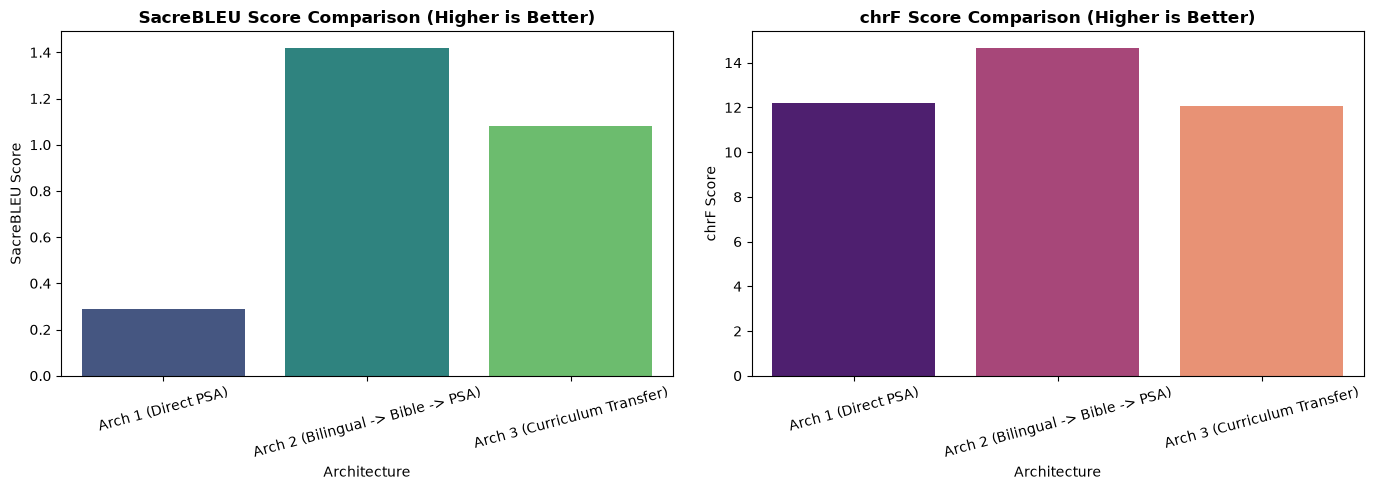

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

results_data = [
    {'Architecture': 'Arch 1 (Direct PSA)', 'SacreBLEU': round(bleu1, 2), 'chrF': round(chrf1, 2)},
    {'Architecture': 'Arch 2 (Bilingual -> Bible -> PSA)', 'SacreBLEU': round(bleu2, 2), 'chrF': round(chrf2, 2)},
    {'Architecture': 'Arch 3 (Curriculum Transfer)', 'SacreBLEU': round(bleu3, 2), 'chrF': round(chrf3, 2)}
]

df_results = pd.DataFrame(results_data)
print('=== 📊 FINAL ARCHITECTURE BENCHMARK EVALUATION TABLE ===')
display(df_results)

# Plot Comparison Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_results, x='Architecture', y='SacreBLEU', ax=axes[0], palette='viridis')
axes[0].set_title('SacreBLEU Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('SacreBLEU Score')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=df_results, x='Architecture', y='chrF', ax=axes[1], palette='magma')
axes[1].set_title('chrF Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('chrF Score')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()